In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

import scipy.sparse as sparse

In [20]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [21]:
with open('configs/ryanComp.pkl', 'rb') as f:
    a1 = pickle.load(f)

In [36]:
sim.distillation.generateDistillFile(modelObj=a1,filePath="./configs/ryanComp.hdf5",numVecs=5,autocorrSkip=10,DNums=(0,2))

Generating distill data:   0%|          | 0/400 [00:00<?, ?it/s]

'./configs/ryanComp.hdf5'

In [37]:
path = "./configs/ryanComp.hdf5"
meta = sim.distillation.readDistillMeta(path)

basis1 = [sim.distillation.MesonOp("g5"),sim.distillation.MesonOp("g5",DNum=2)]
basis2 = [sim.distillation.MesonOp("g5"),sim.distillation.MesonOp("g5",DNum=2),sim.distillation.MesonOp("gx"),sim.distillation.MesonOp("gx",DNum=2)]

corrs1 = sim.GEVP.measureEnsemble2pt(path,meta.configIndices,basis=basis1)
corrs2 = sim.GEVP.measureEnsemble2pt(path,meta.configIndices,basis=basis2)

/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


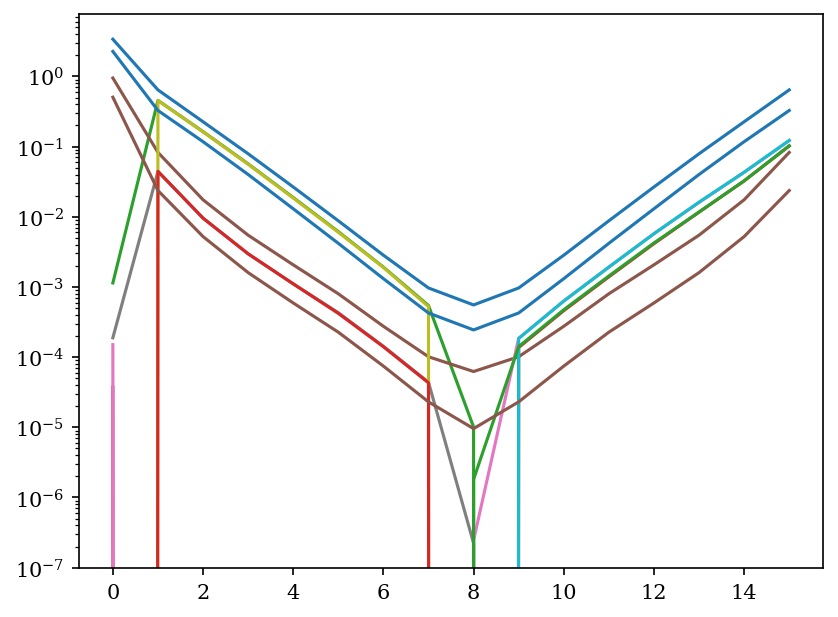

In [39]:
plt.figure(dpi=150)
plt.semilogy(np.reshape(corrs2[0],(16,-1)).T);

In [40]:
gevpTi = 2   # reference time used inside gevpReduce: lambda(gevpTi) = 1, curves start there

gevpOut1 = sim.GEVP.bootstrapEnsemble2pt(corrs1, reduce=lambda C: sim.GEVP.gevpReduce(C, ti=gevpTi))
gevpOut2 = sim.GEVP.bootstrapEnsemble2pt(corrs2, reduce=lambda C: sim.GEVP.gevpReduce(C, ti=gevpTi))

In [ ]:
# fitT is in curve-index units m = t - gevpTi; window [3,6] = actual times 4..6

m0 = sim.correlation.gevpMassExtract(gevpOut2, fitT=[2,6], ti=gevpTi, eigenIdx=0,coshExpr=False)
m1 = sim.correlation.gevpMassExtract(gevpOut2, fitT=[2,6], ti=gevpTi, eigenIdx=1,coshExpr=False)

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/correlation.py:336: RuntimeWarning: invalid value encountered in log
  log_mean = np.log(mean)


ValueError: array must not contain infs or NaNs

In [42]:
print(m0)
print(m1)

[0.96858923 0.00312263]
[1.00652219e-11 9.43014471e-02]


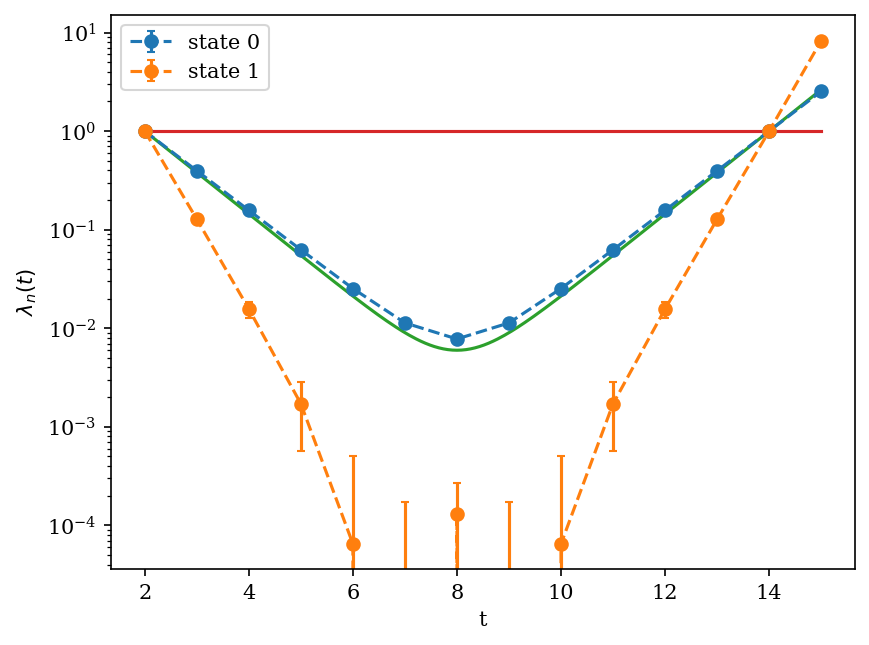

In [43]:
central, err, cov = gevpOut1

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=f"state {e}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)
plt.plot(tf, coshCorrel(tf, m0[0], gevpTi, meta.dimt))
plt.plot(tf, coshCorrel(tf, m1[0], gevpTi, meta.dimt))

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

[]

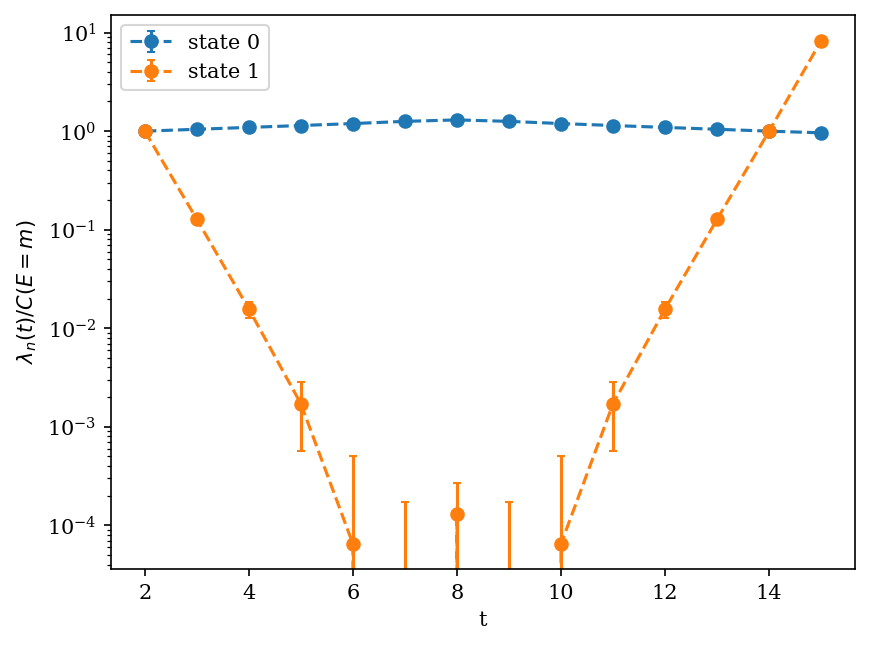

In [44]:
fits = [coshCorrel(ts, m0[0], gevpTi, meta.dimt), coshCorrel(ts, m1[0], gevpTi, meta.dimt)]

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e]/fits[e], yerr=err[::-1, :, e]/fits[e],
                 fmt='o--', capsize=2, label=f"state {e}")
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)/C(E=m)$")
plt.legend()
plt.semilogy()

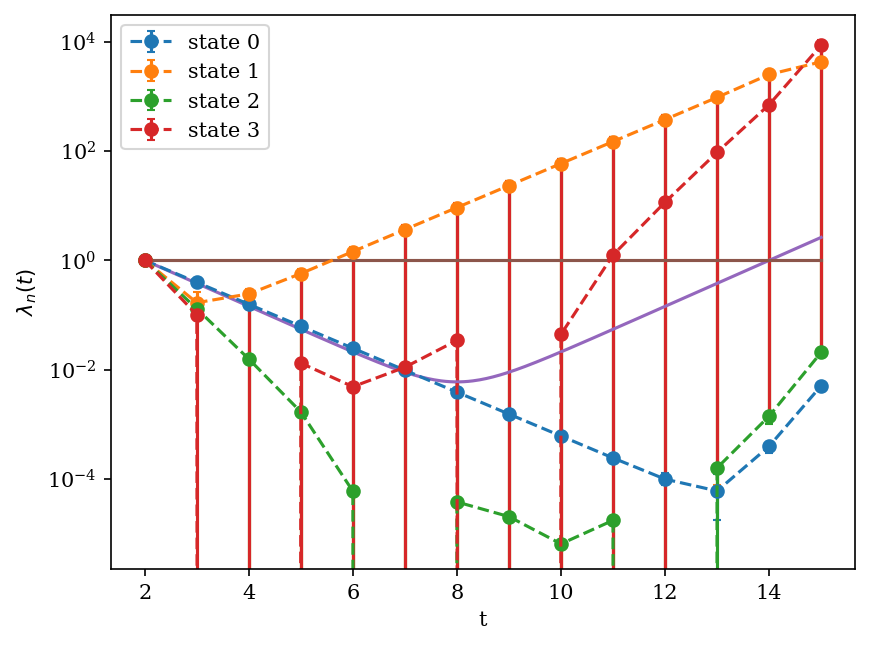

In [45]:
central, err, cov = gevpOut2

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=f"state {e}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)
plt.plot(tf, coshCorrel(tf, m0[0], gevpTi, meta.dimt))
plt.plot(tf, coshCorrel(tf, m1[0], gevpTi, meta.dimt))

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()